In [1]:
!ls


daily             monthly           state_model.ipynb


In [1]:
# ============================================================
# MEMORY-SAFE STRAVA DAILY -> MONTHLY AGGREGATION
# ------------------------------------------------------------
# Reads large CSVs in chunks instead of loading them completely.
#
# Input:
#   State_model/daily/
#
# Output:
#   State_model/clean monthly/
# ============================================================

from pathlib import Path
import gc
import re
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 0. PATHS AND SETTINGS
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()
DAILY_DIR = PROJECT_DIR / "daily"
MONTHLY_DIR = PROJECT_DIR / "monthly"
OUTPUT_DIR = PROJECT_DIR / "clean monthly"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reduce this to 25_000 if memory remains an issue.
CHUNK_SIZE = 100_000

print("Project directory:", PROJECT_DIR)
print("Daily directory:", DAILY_DIR)
print("Monthly reference directory:", MONTHLY_DIR)
print("Output directory:", OUTPUT_DIR)


# ------------------------------------------------------------
# 1. HELPER FUNCTIONS
# ------------------------------------------------------------

def normalize_name(value):
    """Normalize a column name for comparison."""
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_")


def find_date_column(columns):
    """Find the daily date column from column names."""
    lookup = {
        normalize_name(column): column
        for column in columns
    }

    preferred = [
        "date",
        "activity_date",
        "start_date",
        "day",
        "datetime",
        "date_time",
        "timestamp",
    ]

    for candidate in preferred:
        if candidate in lookup:
            return lookup[candidate]

    for normalized, original in lookup.items():
        if "date" in normalized:
            return original

    return None


def identify_metric_columns(sample_df, date_column):
    """
    Identify columns that should be summed from daily to monthly.

    Strava activity/count columns are summed. Identifiers, coordinates,
    dates, years and months are not summed.
    """
    metric_keywords = [
        "count",
        "trips",
        "trip",
        "activities",
        "activity",
        "athletes",
        "athlete",
        "commute",
        "leisure",
        "forward",
        "reverse",
        "volume",
        "total",
    ]

    identifier_keywords = [
        "id",
        "uid",
        "index",
        "latitude",
        "longitude",
        "lat",
        "lon",
        "lng",
        "year",
        "month",
        "day",
        "length",
        "distance",
        "speed",
        "geometry",
        "wkt",
    ]

    metric_columns = []

    for column in sample_df.columns:
        normalized = normalize_name(column)

        if column == date_column:
            continue

        if any(keyword in normalized for keyword in identifier_keywords):
            continue

        if any(keyword in normalized for keyword in metric_keywords):
            converted = pd.to_numeric(
                sample_df[column],
                errors="coerce",
            )

            if converted.notna().any():
                metric_columns.append(column)

    return metric_columns


def identify_group_columns(sample_df, date_column, metric_columns):
    """
    Keep all nonmetric columns as identifiers or categories.

    This typically preserves edge ID, activity type, direction,
    street/trail information and other Strava dimensions.
    """
    excluded = set(metric_columns) | {date_column}

    temporal_names = {
        "year",
        "month",
        "day",
        "start_date",
        "end_date",
    }

    group_columns = []

    for column in sample_df.columns:
        normalized = normalize_name(column)

        if column in excluded:
            continue

        if normalized in temporal_names:
            continue

        group_columns.append(column)

    return group_columns


def aggregate_one_file(input_path, output_path):
    """Aggregate one large daily CSV using chunks."""

    print(f"\nReading header: {input_path}")

    # Only read a small sample to determine the schema.
    sample = pd.read_csv(
        input_path,
        nrows=1_000,
        low_memory=False,
    )

    print("Columns:")
    print(list(sample.columns))

    date_column = find_date_column(sample.columns)

    if date_column is None:
        raise ValueError(
            f"No date column found in {input_path.name}. "
            f"Columns were: {list(sample.columns)}"
        )

    metric_columns = identify_metric_columns(
        sample_df=sample,
        date_column=date_column,
    )

    if not metric_columns:
        raise ValueError(
            f"No count/activity metric columns were detected in "
            f"{input_path.name}.\n"
            f"Columns were: {list(sample.columns)}"
        )

    group_columns = identify_group_columns(
        sample_df=sample,
        date_column=date_column,
        metric_columns=metric_columns,
    )

    print("Date column:", date_column)
    print("Metric columns to sum:", metric_columns)
    print("Grouping columns:", group_columns)

    del sample
    gc.collect()

    partial_results = []
    rows_read = 0

    reader = pd.read_csv(
        input_path,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    )

    for chunk_number, chunk in enumerate(reader, start=1):

        rows_read += len(chunk)

        # Parse dates.
        chunk[date_column] = pd.to_datetime(
            chunk[date_column],
            errors="coerce",
        )

        chunk = chunk.dropna(subset=[date_column])

        if chunk.empty:
            continue

        # Monthly date represented by the first day of the month.
        chunk["start_date"] = (
            chunk[date_column]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        # Ensure metric columns are numeric.
        for column in metric_columns:
            chunk[column] = pd.to_numeric(
                chunk[column],
                errors="coerce",
            ).fillna(0)

        grouping_columns = ["start_date"] + group_columns

        # Aggregate this chunk.
        chunk_monthly = (
            chunk
            .groupby(
                grouping_columns,
                dropna=False,
                observed=True,
                as_index=False,
            )[metric_columns]
            .sum()
        )

        partial_results.append(chunk_monthly)

        print(
            f"  Chunk {chunk_number:,}: "
            f"{rows_read:,} total rows read; "
            f"{len(chunk_monthly):,} partial monthly rows"
        )

        del chunk
        del chunk_monthly
        gc.collect()

    if not partial_results:
        raise ValueError(
            f"No valid dated records were found in {input_path.name}."
        )

    print("Combining chunk-level monthly results...")

    # Combining partial aggregates is much smaller than combining raw data.
    combined = pd.concat(
        partial_results,
        ignore_index=True,
    )

    del partial_results
    gc.collect()

    grouping_columns = ["start_date"] + group_columns

    monthly = (
        combined
        .groupby(
            grouping_columns,
            dropna=False,
            observed=True,
            as_index=False,
        )[metric_columns]
        .sum()
    )

    del combined
    gc.collect()

    monthly = monthly.sort_values(
        grouping_columns
    ).reset_index(drop=True)

    monthly.to_csv(
        output_path,
        index=False,
        date_format="%Y-%m-%d",
    )

    print(f"Saved: {output_path}")
    print(f"Input daily rows: {rows_read:,}")
    print(f"Output monthly rows: {len(monthly):,}")

    result = {
        "input_file": str(input_path.relative_to(DAILY_DIR)),
        "output_file": str(output_path.relative_to(OUTPUT_DIR)),
        "daily_rows": rows_read,
        "monthly_rows": len(monthly),
        "date_column": date_column,
        "metric_columns": " | ".join(metric_columns),
        "group_columns": " | ".join(group_columns),
        "status": "success",
        "error": None,
    }

    del monthly
    gc.collect()

    return result


# ------------------------------------------------------------
# 2. LOCATE DAILY CSV FILES
# ------------------------------------------------------------

daily_files = sorted(DAILY_DIR.rglob("*.csv"))

print(f"\nDaily CSV files found: {len(daily_files)}")

if not daily_files:
    raise FileNotFoundError(
        f"No CSV files found under {DAILY_DIR}"
    )


# ------------------------------------------------------------
# 3. PROCESS FILES ONE AT A TIME
# ------------------------------------------------------------

summary_records = []

for file_number, input_path in enumerate(daily_files, start=1):

    relative_path = input_path.relative_to(DAILY_DIR)

    # Preserve daily subfolder structure inside clean monthly.
    output_subfolder = OUTPUT_DIR / relative_path.parent
    output_subfolder.mkdir(parents=True, exist_ok=True)

    output_path = (
        output_subfolder /
        f"{input_path.stem}_monthly.csv"
    )

    print("\n" + "=" * 70)
    print(
        f"FILE {file_number} OF {len(daily_files)}: "
        f"{relative_path}"
    )
    print("=" * 70)

    try:
        result = aggregate_one_file(
            input_path=input_path,
            output_path=output_path,
        )

    except Exception as error:
        print(f"FAILED: {error}")

        result = {
            "input_file": str(relative_path),
            "output_file": None,
            "daily_rows": None,
            "monthly_rows": None,
            "date_column": None,
            "metric_columns": None,
            "group_columns": None,
            "status": "failed",
            "error": str(error),
        }

    summary_records.append(result)

    # Save progress after every file so a crash does not lose the summary.
    summary_df = pd.DataFrame(summary_records)

    summary_df.to_csv(
        OUTPUT_DIR / "_aggregation_summary.csv",
        index=False,
    )

    gc.collect()


# ------------------------------------------------------------
# 4. FINAL SUMMARY
# ------------------------------------------------------------

summary_df = pd.DataFrame(summary_records)

successful = (summary_df["status"] == "success").sum()
failed = (summary_df["status"] == "failed").sum()

print("\n" + "=" * 70)
print("AGGREGATION FINISHED")
print("=" * 70)
print(f"Successful files: {successful}")
print(f"Failed files: {failed}")
print(f"Outputs: {OUTPUT_DIR}")
print(
    "Summary:",
    OUTPUT_DIR / "_aggregation_summary.csv",
)

display(summary_df)

Project directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model
Daily directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily
Monthly reference directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/monthly
Output directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/clean monthly

Daily CSV files found: 14

FILE 1 OF 14: all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv

Reading header: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv
Columns:
['edge_uid', 'a

,input_file,output_file,daily_rows,monthly_rows,date_column,metric_columns,group_columns,status,error
0,all_edges_daily_2021-01-01-2021-03-31_ped/aa73...,all_edges_daily_2021-01-01-2021-03-31_ped/aa73...,8603711,8560595,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
1,all_edges_daily_2021-04-01-2021-06-30_ped/56a3...,all_edges_daily_2021-04-01-2021-06-30_ped/56a3...,9972150,9916922,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
2,all_edges_daily_2021-07-01-2021-09-30_ped/3ba6...,all_edges_daily_2021-07-01-2021-09-30_ped/3ba6...,10383740,10323537,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
3,all_edges_daily_2021-10-01-2021-12-31_ped/c34c...,all_edges_daily_2021-10-01-2021-12-31_ped/c34c...,8624967,8580693,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
4,all_edges_daily_2022-01-01-2022-03-31_ped/6960...,all_edges_daily_2022-01-01-2022-03-31_ped/6960...,8003560,7966076,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
5,all_edges_daily_2022-04-01-2022-06-30_ped/2bb1...,all_edges_daily_2022-04-01-2022-06-30_ped/2bb1...,9594052,9544609,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
6,all_edges_daily_2022-07-01-2022-09-30_ped/28f5...,all_edges_daily_2022-07-01-2022-09-30_ped/28f5...,10422724,10363482,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
7,all_edges_daily_2022-10-01-2022-12-31_ped/17a2...,all_edges_daily_2022-10-01-2022-12-31_ped/17a2...,8120695,8081261,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
8,all_edges_daily_2023-01-01-2023-03-31_ped/276b...,all_edges_daily_2023-01-01-2023-03-31_ped/276b...,9146255,9102893,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None
9,all_edges_daily_2023-04-01-2023-06-30_ped/fd3b...,all_edges_daily_2023-04-01-2023-06-30_ped/fd3b...,10673228,10619456,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,None


In [2]:
from pathlib import Path
import pandas as pd

MONTHLY_DIR = Path("monthly")
CLEAN_MONTHLY_DIR = Path("clean monthly")

monthly_files = sorted(MONTHLY_DIR.rglob("*.csv"))
clean_files = sorted(CLEAN_MONTHLY_DIR.rglob("*.csv"))

print("Original monthly files:")
for path in monthly_files:
    print(" ", path)

print("\nClean monthly files:")
for path in clean_files[:10]:
    print(" ", path)

# Inspect one original monthly file
if monthly_files:
    original_path = monthly_files[0]

    original_sample = pd.read_csv(
        original_path,
        nrows=5,
        low_memory=False,
    )

    print("\nORIGINAL MONTHLY FILE:")
    print(original_path)
    print("\nColumns:")
    print(original_sample.columns.tolist())

    print("\nSample:")
    display(original_sample)

    print("\nData types:")
    print(original_sample.dtypes)

# Inspect one cleaned monthly file
if clean_files:
    clean_path = clean_files[0]

    clean_sample = pd.read_csv(
        clean_path,
        nrows=5,
        low_memory=False,
    )

    print("\nCLEAN MONTHLY FILE:")
    print(clean_path)
    print("\nColumns:")
    print(clean_sample.columns.tolist())

    print("\nSample:")
    display(clean_sample)

    print("\nData types:")
    print(clean_sample.dtypes)

Original monthly files:
  monthly/all_edges_monthly_jan_2024-dec_2024_ped/5d8dd8206927acba134c8de613dc0ed21dca591b09404dff7c96de9270e0689d-1784091414895.csv
  monthly/all_edges_monthly_jan_2025-dec_2025_ped/955d3eb37479f5f29fa699267d0cfa89b0c030e97e677535d92d5daaa90c6627-1784093301203.csv

Clean monthly files:
  clean monthly/_aggregation_summary.csv
  clean monthly/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996_monthly.csv
  clean monthly/all_edges_daily_2021-04-01-2021-06-30_ped/56a3677547782a17492f76e2eb35ccec07ff3ba19109259bb0ef8a8d30b52a4c-1784044632465_monthly.csv
  clean monthly/all_edges_daily_2021-07-01-2021-09-30_ped/3ba60c51e13f61cceff6bd12bd5bb67786fdf126ebda04f02c3e95b0afe524b2-1784057158681_monthly.csv
  clean monthly/all_edges_daily_2021-10-01-2021-12-31_ped/c34c9e8f0d93f5fa554a7506a23dc66b5c9f8cbcc61e2ba9d35dd99a6254f81c-1784128143320_monthly.csv
  clean monthly/all_edges_daily_2022-01-01-2022-03-

,edge_uid,activity_type,month,total_trip_count,forward_trip_count,reverse_trip_count,forward_people_count,reverse_people_count,forward_commute_trip_count,reverse_commute_trip_count,...,reverse_18_34_people_count,forward_35_54_people_count,reverse_35_54_people_count,forward_55_64_people_count,reverse_55_64_people_count,forward_65_plus_people_count,reverse_65_plus_people_count,forward_average_speed_meters_per_second,reverse_average_speed_meters_per_second,osm_reference_id
0,511120914,"Run,Walk,Hike",2024-12,15,5,5,5,5,5,5,...,5,0,5,0,0,0,0,1.69,1.79,1239743555
1,511288626,"Run,Walk,Hike",2024-07,15,5,10,5,5,0,5,...,5,0,5,0,0,0,0,2.78,2.62,1155230644
2,510939741,"Run,Walk,Hike",2024-05,15,10,5,10,5,0,0,...,0,5,5,0,0,0,0,2.88,2.39,1293323101
3,511613938,"Run,Walk,Hike",2024-08,30,15,15,5,5,0,0,...,0,0,0,0,0,0,0,2.64,3.08,1127882504
4,514670301,"Run,Walk,Hike",2024-07,15,5,5,5,5,0,0,...,0,0,5,0,0,0,0,3.15,3.57,223838766



Data types:
edge_uid                                     int64
activity_type                               object
month                                       object
total_trip_count                             int64
forward_trip_count                           int64
reverse_trip_count                           int64
forward_people_count                         int64
reverse_people_count                         int64
forward_commute_trip_count                   int64
reverse_commute_trip_count                   int64
forward_leisure_trip_count                   int64
reverse_leisure_trip_count                   int64
forward_morning_trip_count                   int64
reverse_morning_trip_count                   int64
forward_midday_trip_count                    int64
reverse_midday_trip_count                    int64
forward_evening_trip_count                   int64
reverse_evening_trip_count                   int64
forward_overnight_trip_count                 int64
reverse_overnight_

,input_file,output_file,daily_rows,monthly_rows,date_column,metric_columns,group_columns,status,error
0,all_edges_daily_2021-01-01-2021-03-31_ped/aa73...,all_edges_daily_2021-01-01-2021-03-31_ped/aa73...,8603711,8560595,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,NaN
1,all_edges_daily_2021-04-01-2021-06-30_ped/56a3...,all_edges_daily_2021-04-01-2021-06-30_ped/56a3...,9972150,9916922,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,NaN
2,all_edges_daily_2021-07-01-2021-09-30_ped/3ba6...,all_edges_daily_2021-07-01-2021-09-30_ped/3ba6...,10383740,10323537,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,NaN
3,all_edges_daily_2021-10-01-2021-12-31_ped/c34c...,all_edges_daily_2021-10-01-2021-12-31_ped/c34c...,8624967,8580693,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,NaN
4,all_edges_daily_2022-01-01-2022-03-31_ped/6960...,all_edges_daily_2022-01-01-2022-03-31_ped/6960...,8003560,7966076,date,total_trip_count | forward_trip_count | revers...,edge_uid | activity_type | forward_midday_trip...,success,NaN



Data types:
input_file         object
output_file        object
daily_rows          int64
monthly_rows        int64
date_column        object
metric_columns     object
group_columns      object
status             object
error             float64
dtype: object


In [3]:
from pathlib import Path

for path in Path(".").rglob("*"):
    if path.is_file() and path.suffix.lower() in {
        ".csv", ".shp", ".geojson", ".json", ".gpkg"
    }:
        print(path)

daily/all_edges_daily_2023-07-01-2023-09-30_ped/0b1a74c118bdeaac0cced0fdfc0c426865b8e3ede66d565d2707ab8bf90e960f-1784079511631.shp
daily/all_edges_daily_2023-07-01-2023-09-30_ped/0b1a74c118bdeaac0cced0fdfc0c426865b8e3ede66d565d2707ab8bf90e960f-1784079511631.csv
daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.shp
daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv
daily/all_edges_daily_2022-07-01-2022-09-30_ped/28f54a190c57b9ff8e8ff1bb417ca9e7f1bfa4c086b4e2491a29ed81b4ec51c3-1784062010296.csv
daily/all_edges_daily_2022-07-01-2022-09-30_ped/28f54a190c57b9ff8e8ff1bb417ca9e7f1bfa4c086b4e2491a29ed81b4ec51c3-1784062010296.shp
daily/all_edges_daily_2023-01-01-2023-03-31_ped/276ba281a71e0abae50eca42a13df788812ae00662dd52d6553f1753c92dac18-1784073644464.shp
daily/all_edges_daily_2023-01-01-2023-03-31_ped/276ba281a71e0abae50eca42a13df788812

In [4]:
# ============================================================
# STRAVA ACTIVITY OVER TIME FOR THREE ALLTRAILS TRAILS
# ------------------------------------------------------------
# Expected folders:
#
# State_model/
# ├── daily/
# ├── monthly/
# ├── trails/
# │   ├── Ashokan_high_point_trail.js
# │   ├── Pine_hill_west_branch_trail.js
# │   └── Vernooy_falls_trail.js
# └── state_model.ipynb
#
# This script:
#   1. Loads the three AllTrails GeoJSON/JS files
#   2. Finds nearby Strava edges using the shapefiles
#   3. Reads daily files for 2021-2023 and 2026 in chunks
#   4. Reads monthly files for 2024-2025
#   5. Aggregates total_trip_count by month and trail
#   6. Produces a continuous monthly plot
# ============================================================

from pathlib import Path
import gc
import json
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import shape
from shapely.ops import unary_union

In [5]:
# ============================================================
# 1. PATHS AND SETTINGS
# ============================================================

PROJECT_DIR = Path.cwd()

DAILY_DIR = PROJECT_DIR / "daily"
MONTHLY_DIR = PROJECT_DIR / "monthly"
TRAIL_DIR = PROJECT_DIR / "trails"
OUTPUT_DIR = PROJECT_DIR / "trail_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIL_FILES = {
    "Ashokan High Point Trail": TRAIL_DIR / "Ashokan_high_point_trail.js",
    "Pine Hill West Branch Trail": TRAIL_DIR / "Pine_hill_west_branch_trail.js",
    "Vernooy Falls Trail": TRAIL_DIR / "Vernooy_falls_trail.js",
}

BUFFER_METERS = 30
CHUNK_SIZE = 250_000
ACTIVITY_TYPE_FILTER = "Run,Walk,Hike"

print("Project directory:", PROJECT_DIR)
print("Daily directory:", DAILY_DIR)
print("Monthly directory:", MONTHLY_DIR)
print("Trail directory:", TRAIL_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model
Daily directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily
Monthly directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/monthly
Trail directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trails
Output directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trail_outputs


In [6]:
# ============================================================
# 2. LOAD ALLTRAILS GEOJSON / JS FILES
# ============================================================

def load_alltrails_file(path):
    text = path.read_text(encoding="utf-8").strip()

    # Support files formatted as:
    # variable_name = {...}
    # or:
    # variable_name: {...}
    # or plain GeoJSON.
    first_brace = text.find("{")
    last_brace = text.rfind("}")

    if first_brace == -1 or last_brace == -1:
        raise ValueError(f"No JSON object found in {path}")

    json_text = text[first_brace:last_brace + 1]
    data = json.loads(json_text)

    if data.get("type") == "FeatureCollection":
        features = data["features"]
    elif data.get("type") == "Feature":
        features = [data]
    else:
        raise ValueError(
            f"Unsupported GeoJSON type in {path}: {data.get('type')}"
        )

    geometries = [
        shape(feature["geometry"])
        for feature in features
        if feature.get("geometry") is not None
    ]

    if not geometries:
        raise ValueError(f"No geometry found in {path}")

    geometry = unary_union(geometries)

    return gpd.GeoDataFrame(
        {"trail_name": [path.stem]},
        geometry=[geometry],
        crs="EPSG:4326",
    )


trail_frames = []

for trail_name, trail_path in TRAIL_FILES.items():
    if not trail_path.exists():
        raise FileNotFoundError(f"Missing trail file: {trail_path}")

    trail_gdf = load_alltrails_file(trail_path)
    trail_gdf["trail_name"] = trail_name
    trail_frames.append(trail_gdf)

trails = gpd.GeoDataFrame(
    pd.concat(trail_frames, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326",
)

display(trails)

,trail_name,geometry
0,Ashokan High Point Trail,"MULTILINESTRING Z ((-74.328 41.93582 358, -74...."
1,Pine Hill West Branch Trail,"MULTILINESTRING Z ((-74.48418 41.99143 650, -7..."
2,Vernooy Falls Trail,"MULTILINESTRING Z ((-74.34586 41.86409 384, -7..."


In [7]:
# ============================================================
# 3. LOAD ONE STRAVA SHAPEFILE AND INSPECT ITS COLUMNS
# ============================================================

strava_shapefiles = sorted(
    list(DAILY_DIR.rglob("*.shp")) +
    list(MONTHLY_DIR.rglob("*.shp"))
)

if not strava_shapefiles:
    raise FileNotFoundError("No Strava shapefiles were found.")

reference_shapefile = strava_shapefiles[0]

print("Reference shapefile:", reference_shapefile)

strava_edges = gpd.read_file(reference_shapefile)

print("CRS:", strava_edges.crs)
print("Columns:")
print(strava_edges.columns.tolist())

display(strava_edges.head())

Reference shapefile: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.shp
CRS: EPSG:4326
Columns:
['edgeUID', 'osmId', 'geometry']


,edgeUID,osmId,geometry
0,495789196,746506456,"LINESTRING (-79.74323 42.06087, -79.74319 42.0..."
1,495789314,1024912209,"LINESTRING (-79.73995 42.06217, -79.73954 42.0..."
2,495789612,910088922,"LINESTRING (-79.63386 42.02079, -79.63379 42.0..."
3,495790528,946158337,"LINESTRING (-79.76195 42.18379, -79.76184 42.1..."
4,495790834,38653339,"LINESTRING (-79.65194 42.14727, -79.65099 42.1..."


In [8]:
# ============================================================
# 4. FIND THE EDGE UID COLUMN
# ============================================================

def find_edge_uid_column(columns):
    normalized = {
        re.sub(r"[^a-z0-9]+", "_", str(column).lower()).strip("_"): column
        for column in columns
    }

    candidates = [
        "edge_uid",
        "edge_id",
        "edgeuid",
        "edgeid",
    ]

    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]

    for normalized_name, original_name in normalized.items():
        if "edge" in normalized_name and "uid" in normalized_name:
            return original_name

    raise ValueError(
        f"Could not identify edge UID column. Columns: {list(columns)}"
    )


EDGE_UID_COLUMN = find_edge_uid_column(strava_edges.columns)

print("Edge UID column:", EDGE_UID_COLUMN)

Edge UID column: edgeUID


In [9]:
# ============================================================
# 5. PROJECT TRAILS AND EDGES INTO A METRIC CRS
# ============================================================

if strava_edges.crs is None:
    raise ValueError("The Strava shapefile has no CRS.")

strava_edges = strava_edges[
    [EDGE_UID_COLUMN, "geometry"]
].copy()

strava_edges = strava_edges.dropna(
    subset=[EDGE_UID_COLUMN, "geometry"]
)

strava_edges[EDGE_UID_COLUMN] = pd.to_numeric(
    strava_edges[EDGE_UID_COLUMN],
    errors="coerce",
)

strava_edges = strava_edges.dropna(
    subset=[EDGE_UID_COLUMN]
)

strava_edges[EDGE_UID_COLUMN] = (
    strava_edges[EDGE_UID_COLUMN]
    .astype("int64")
)

# UTM Zone 18N is suitable for the Catskills.
METRIC_CRS = "EPSG:32618"

trails_metric = trails.to_crs(METRIC_CRS)
edges_metric = strava_edges.to_crs(METRIC_CRS)

print("Trails projected CRS:", trails_metric.crs)
print("Edges projected CRS:", edges_metric.crs)

Trails projected CRS: EPSG:32618
Edges projected CRS: EPSG:32618


In [10]:
# ============================================================
# 6. FIND STRAVA EDGES NEAR EACH TRAIL
# ============================================================

trail_edge_sets = {}
trail_edge_summary = []

for _, trail_row in trails_metric.iterrows():

    trail_name = trail_row["trail_name"]
    trail_geometry = trail_row.geometry

    trail_buffer = trail_geometry.buffer(BUFFER_METERS)

    possible_index = list(
        edges_metric.sindex.query(
            trail_buffer,
            predicate="intersects",
        )
    )

    possible_edges = edges_metric.iloc[possible_index].copy()

    selected_edges = possible_edges[
        possible_edges.geometry.intersects(trail_buffer)
    ].copy()

    selected_edge_uids = set(
        selected_edges[EDGE_UID_COLUMN]
        .dropna()
        .astype("int64")
        .tolist()
    )

    trail_edge_sets[trail_name] = selected_edge_uids

    trail_edge_summary.append({
        "trail_name": trail_name,
        "buffer_meters": BUFFER_METERS,
        "selected_edges": len(selected_edge_uids),
    })

trail_edge_summary_df = pd.DataFrame(trail_edge_summary)

display(trail_edge_summary_df)

,trail_name,buffer_meters,selected_edges
0,Ashokan High Point Trail,30,33
1,Pine Hill West Branch Trail,30,51
2,Vernooy Falls Trail,30,21


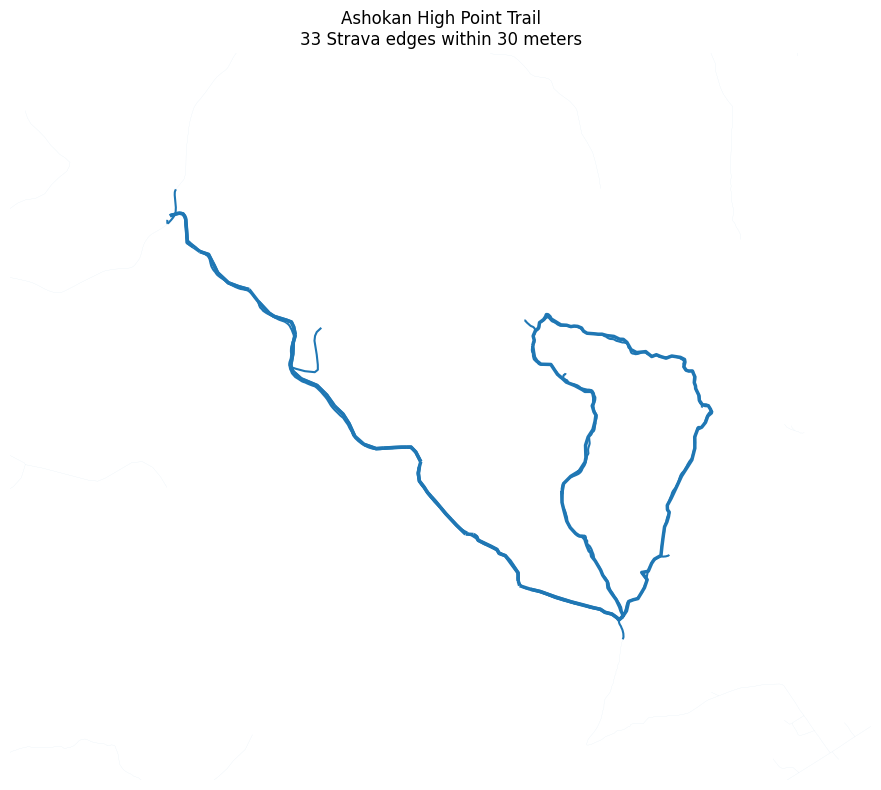

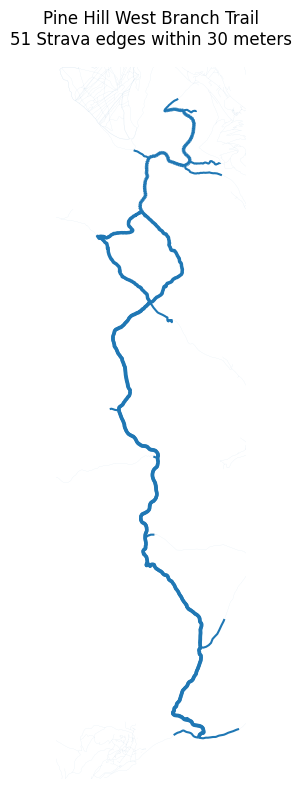

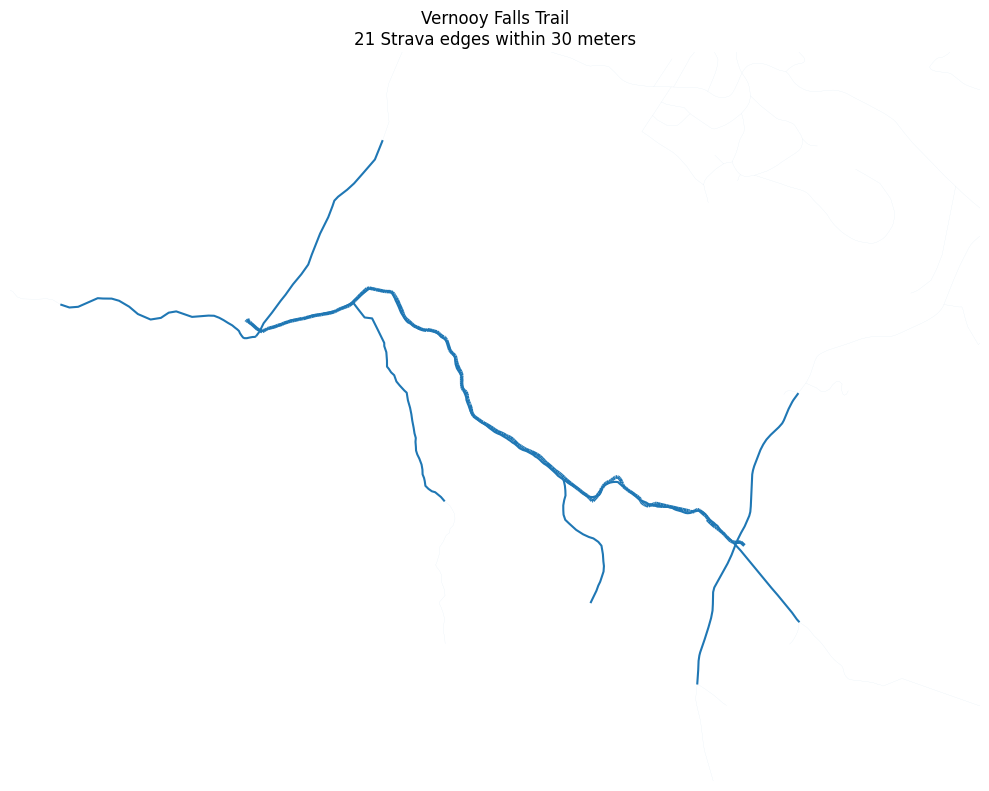

In [11]:
# ============================================================
# 7. MAP SELECTED EDGES FOR VISUAL CHECK
# ============================================================

for trail_name in trails_metric["trail_name"]:

    trail_geometry = trails_metric.loc[
        trails_metric["trail_name"] == trail_name,
        "geometry",
    ].iloc[0]

    selected_ids = trail_edge_sets[trail_name]

    selected_edges = edges_metric[
        edges_metric[EDGE_UID_COLUMN].isin(selected_ids)
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    edges_metric.plot(
        ax=ax,
        linewidth=0.15,
        alpha=0.15,
    )

    selected_edges.plot(
        ax=ax,
        linewidth=1.5,
    )

    gpd.GeoSeries(
        [trail_geometry],
        crs=METRIC_CRS,
    ).plot(
        ax=ax,
        linewidth=2.5,
    )

    minx, miny, maxx, maxy = trail_geometry.buffer(1000).bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(
        f"{trail_name}\n"
        f"{len(selected_ids):,} Strava edges within "
        f"{BUFFER_METERS} meters"
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================
# 8. CREATE EDGE-TO-TRAIL LOOKUP
# ============================================================

edge_to_trails = {}

for trail_name, edge_set in trail_edge_sets.items():
    for edge_uid in edge_set:
        edge_to_trails.setdefault(edge_uid, []).append(trail_name)

all_selected_edge_uids = set(edge_to_trails)

print("Unique selected edge UIDs:", len(all_selected_edge_uids))

for trail_name, edge_set in trail_edge_sets.items():
    print(trail_name, len(edge_set))

Unique selected edge UIDs: 105
Ashokan High Point Trail 33
Pine Hill West Branch Trail 51
Vernooy Falls Trail 21


In [13]:
# ============================================================
# 9. HELPER FOR ASSIGNING MATCHED EDGES TO TRAILS
# ============================================================

def assign_rows_to_trails(df):
    matched_parts = []

    for trail_name, edge_set in trail_edge_sets.items():

        part = df[df["edge_uid"].isin(edge_set)].copy()

        if part.empty:
            continue

        part["trail_name"] = trail_name
        matched_parts.append(part)

    if not matched_parts:
        return pd.DataFrame()

    return pd.concat(
        matched_parts,
        ignore_index=True,
    )

In [14]:
# ============================================================
# 10. PROCESS DAILY CSV FILES: 2021-2023 AND 2026
# ============================================================

daily_csv_files = sorted(DAILY_DIR.rglob("*.csv"))

daily_results = []

daily_usecols = [
    "edge_uid",
    "activity_type",
    "date",
    "total_trip_count",
]

for file_number, csv_path in enumerate(daily_csv_files, start=1):

    print(
        f"[Daily {file_number}/{len(daily_csv_files)}] "
        f"{csv_path.relative_to(DAILY_DIR)}"
    )

    for chunk in pd.read_csv(
        csv_path,
        usecols=daily_usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    ):

        chunk["edge_uid"] = pd.to_numeric(
            chunk["edge_uid"],
            errors="coerce",
        )

        chunk = chunk.dropna(subset=["edge_uid"])

        chunk["edge_uid"] = (
            chunk["edge_uid"]
            .astype("int64")
        )

        chunk = chunk[
            chunk["edge_uid"].isin(all_selected_edge_uids)
        ]

        if chunk.empty:
            continue

        if ACTIVITY_TYPE_FILTER is not None:
            chunk = chunk[
                chunk["activity_type"] == ACTIVITY_TYPE_FILTER
            ]

        if chunk.empty:
            continue

        chunk["date"] = pd.to_datetime(
            chunk["date"],
            errors="coerce",
        )

        chunk["total_trip_count"] = pd.to_numeric(
            chunk["total_trip_count"],
            errors="coerce",
        ).fillna(0)

        chunk = chunk.dropna(subset=["date"])

        chunk["month"] = (
            chunk["date"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        matched = assign_rows_to_trails(chunk)

        if matched.empty:
            continue

        monthly_part = (
            matched
            .groupby(
                ["trail_name", "month"],
                as_index=False,
            )["total_trip_count"]
            .sum()
        )

        daily_results.append(monthly_part)

        del chunk
        del matched
        del monthly_part
        gc.collect()

print("Daily partial result tables:", len(daily_results))

[Daily 1/14] all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv
[Daily 2/14] all_edges_daily_2021-04-01-2021-06-30_ped/56a3677547782a17492f76e2eb35ccec07ff3ba19109259bb0ef8a8d30b52a4c-1784044632465.csv
[Daily 3/14] all_edges_daily_2021-07-01-2021-09-30_ped/3ba60c51e13f61cceff6bd12bd5bb67786fdf126ebda04f02c3e95b0afe524b2-1784057158681.csv
[Daily 4/14] all_edges_daily_2021-10-01-2021-12-31_ped/c34c9e8f0d93f5fa554a7506a23dc66b5c9f8cbcc61e2ba9d35dd99a6254f81c-1784128143320.csv
[Daily 5/14] all_edges_daily_2022-01-01-2022-03-31_ped/69603f75ef36c804735a3ae4a30f0f5f2e8670390d7394d8660ccd0aa3367108-1784059483406.csv
[Daily 6/14] all_edges_daily_2022-04-01-2022-06-30_ped/2bb180ccf23a4184c2409a297867b7fd70d9a02a32a77773c8d7b170284d5b05-1784060562373.csv
[Daily 7/14] all_edges_daily_2022-07-01-2022-09-30_ped/28f54a190c57b9ff8e8ff1bb417ca9e7f1bfa4c086b4e2491a29ed81b4ec51c3-1784062010296.csv
[Daily 8/14] all_edges_daily_2022-

In [15]:
# ============================================================
# 11. COMBINE DAILY RESULTS
# ============================================================

if daily_results:

    daily_monthly = pd.concat(
        daily_results,
        ignore_index=True,
    )

    daily_monthly = (
        daily_monthly
        .groupby(
            ["trail_name", "month"],
            as_index=False,
        )["total_trip_count"]
        .sum()
    )

else:
    daily_monthly = pd.DataFrame(
        columns=[
            "trail_name",
            "month",
            "total_trip_count",
        ]
    )

daily_monthly["source"] = "daily_aggregated"

display(daily_monthly.head())

,trail_name,month,total_trip_count,source
0,Ashokan High Point Trail,2021-01-01,145,daily_aggregated
1,Ashokan High Point Trail,2021-03-01,40,daily_aggregated
2,Ashokan High Point Trail,2021-05-01,260,daily_aggregated
3,Ashokan High Point Trail,2021-06-01,320,daily_aggregated
4,Ashokan High Point Trail,2021-07-01,265,daily_aggregated


In [16]:
# ============================================================
# 12. PROCESS ORIGINAL MONTHLY CSV FILES: 2024-2025
# ============================================================

monthly_csv_files = sorted(MONTHLY_DIR.rglob("*.csv"))

monthly_results = []

monthly_usecols = [
    "edge_uid",
    "activity_type",
    "month",
    "total_trip_count",
]

for file_number, csv_path in enumerate(monthly_csv_files, start=1):

    print(
        f"[Monthly {file_number}/{len(monthly_csv_files)}] "
        f"{csv_path.relative_to(MONTHLY_DIR)}"
    )

    for chunk in pd.read_csv(
        csv_path,
        usecols=monthly_usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    ):

        chunk["edge_uid"] = pd.to_numeric(
            chunk["edge_uid"],
            errors="coerce",
        )

        chunk = chunk.dropna(subset=["edge_uid"])

        chunk["edge_uid"] = (
            chunk["edge_uid"]
            .astype("int64")
        )

        chunk = chunk[
            chunk["edge_uid"].isin(all_selected_edge_uids)
        ]

        if chunk.empty:
            continue

        if ACTIVITY_TYPE_FILTER is not None:
            chunk = chunk[
                chunk["activity_type"] == ACTIVITY_TYPE_FILTER
            ]

        if chunk.empty:
            continue

        chunk["month"] = pd.to_datetime(
            chunk["month"],
            errors="coerce",
        )

        chunk["total_trip_count"] = pd.to_numeric(
            chunk["total_trip_count"],
            errors="coerce",
        ).fillna(0)

        chunk = chunk.dropna(subset=["month"])

        matched = assign_rows_to_trails(chunk)

        if matched.empty:
            continue

        monthly_part = (
            matched
            .groupby(
                ["trail_name", "month"],
                as_index=False,
            )["total_trip_count"]
            .sum()
        )

        monthly_results.append(monthly_part)

        del chunk
        del matched
        del monthly_part
        gc.collect()

print("Monthly partial result tables:", len(monthly_results))

[Monthly 1/2] all_edges_monthly_jan_2024-dec_2024_ped/5d8dd8206927acba134c8de613dc0ed21dca591b09404dff7c96de9270e0689d-1784091414895.csv
[Monthly 2/2] all_edges_monthly_jan_2025-dec_2025_ped/955d3eb37479f5f29fa699267d0cfa89b0c030e97e677535d92d5daaa90c6627-1784093301203.csv
Monthly partial result tables: 107


In [17]:
# ============================================================
# 13. COMBINE ORIGINAL MONTHLY RESULTS
# ============================================================

if monthly_results:

    original_monthly = pd.concat(
        monthly_results,
        ignore_index=True,
    )

    original_monthly = (
        original_monthly
        .groupby(
            ["trail_name", "month"],
            as_index=False,
        )["total_trip_count"]
        .sum()
    )

else:
    original_monthly = pd.DataFrame(
        columns=[
            "trail_name",
            "month",
            "total_trip_count",
        ]
    )

original_monthly["source"] = "strava_monthly"

display(original_monthly.head())

,trail_name,month,total_trip_count,source
0,Ashokan High Point Trail,2024-01-01,85,strava_monthly
1,Ashokan High Point Trail,2024-02-01,265,strava_monthly
2,Ashokan High Point Trail,2024-03-01,120,strava_monthly
3,Ashokan High Point Trail,2024-04-01,160,strava_monthly
4,Ashokan High Point Trail,2024-05-01,120,strava_monthly


In [18]:
# ============================================================
# 14. COMBINE 2021-2026
# ============================================================

trail_activity = pd.concat(
    [
        daily_monthly,
        original_monthly,
    ],
    ignore_index=True,
)

trail_activity = (
    trail_activity
    .groupby(
        ["trail_name", "month"],
        as_index=False,
    )
    .agg(
        total_trip_count=("total_trip_count", "sum"),
        source=("source", lambda values: "|".join(sorted(set(values)))),
    )
)

trail_activity = trail_activity.sort_values(
    ["trail_name", "month"]
).reset_index(drop=True)

display(trail_activity)

,trail_name,month,total_trip_count,source
0,Ashokan High Point Trail,2021-01-01,145,daily_aggregated
1,Ashokan High Point Trail,2021-03-01,40,daily_aggregated
2,Ashokan High Point Trail,2021-05-01,260,daily_aggregated
3,Ashokan High Point Trail,2021-06-01,320,daily_aggregated
4,Ashokan High Point Trail,2021-07-01,265,daily_aggregated
...,...,...,...,...
143,Vernooy Falls Trail,2025-10-01,375,strava_monthly
144,Vernooy Falls Trail,2025-11-01,215,strava_monthly
145,Vernooy Falls Trail,2025-12-01,280,strava_monthly
146,Vernooy Falls Trail,2026-04-01,15,daily_aggregated


In [19]:
# ============================================================
# 15. HANDLE THE OVERLAP BETWEEN THE TWO 2026 DAILY DOWNLOADS
# ------------------------------------------------------------
# The daily folders overlap during March 2026.
# Because both downloads may contain March 2026, remove duplicate
# source records before summing by using the raw daily files directly.
#
# Check the resulting months for unusually high values.
# ============================================================

overlap_check = (
    trail_activity[
        trail_activity["month"].between(
            "2026-01-01",
            "2026-05-01",
        )
    ]
    .sort_values(
        ["trail_name", "month"]
    )
)

display(overlap_check)

,trail_name,month,total_trip_count,source
36,Ashokan High Point Trail,2026-01-01,10,daily_aggregated
37,Ashokan High Point Trail,2026-05-01,180,daily_aggregated
96,Pine Hill West Branch Trail,2026-01-01,290,daily_aggregated
97,Pine Hill West Branch Trail,2026-02-01,80,daily_aggregated
98,Pine Hill West Branch Trail,2026-03-01,130,daily_aggregated
99,Pine Hill West Branch Trail,2026-04-01,430,daily_aggregated
100,Pine Hill West Branch Trail,2026-05-01,235,daily_aggregated
146,Vernooy Falls Trail,2026-04-01,15,daily_aggregated
147,Vernooy Falls Trail,2026-05-01,95,daily_aggregated


In [20]:
# ============================================================
# 16. CREATE A COMPLETE MONTH GRID
# ============================================================

all_months = pd.date_range(
    trail_activity["month"].min(),
    trail_activity["month"].max(),
    freq="MS",
)

complete_index = pd.MultiIndex.from_product(
    [
        list(TRAIL_FILES.keys()),
        all_months,
    ],
    names=[
        "trail_name",
        "month",
    ],
)

trail_activity_complete = (
    trail_activity
    .set_index(
        ["trail_name", "month"]
    )
    .reindex(complete_index)
    .reset_index()
)

# Missing means no matched Strava observation was found.
# Keep as NaN rather than automatically assuming zero.
display(trail_activity_complete.head())

,trail_name,month,total_trip_count,source
0,Ashokan High Point Trail,2021-01-01,145.0,daily_aggregated
1,Ashokan High Point Trail,2021-02-01,NaN,NaN
2,Ashokan High Point Trail,2021-03-01,40.0,daily_aggregated
3,Ashokan High Point Trail,2021-04-01,NaN,NaN
4,Ashokan High Point Trail,2021-05-01,260.0,daily_aggregated


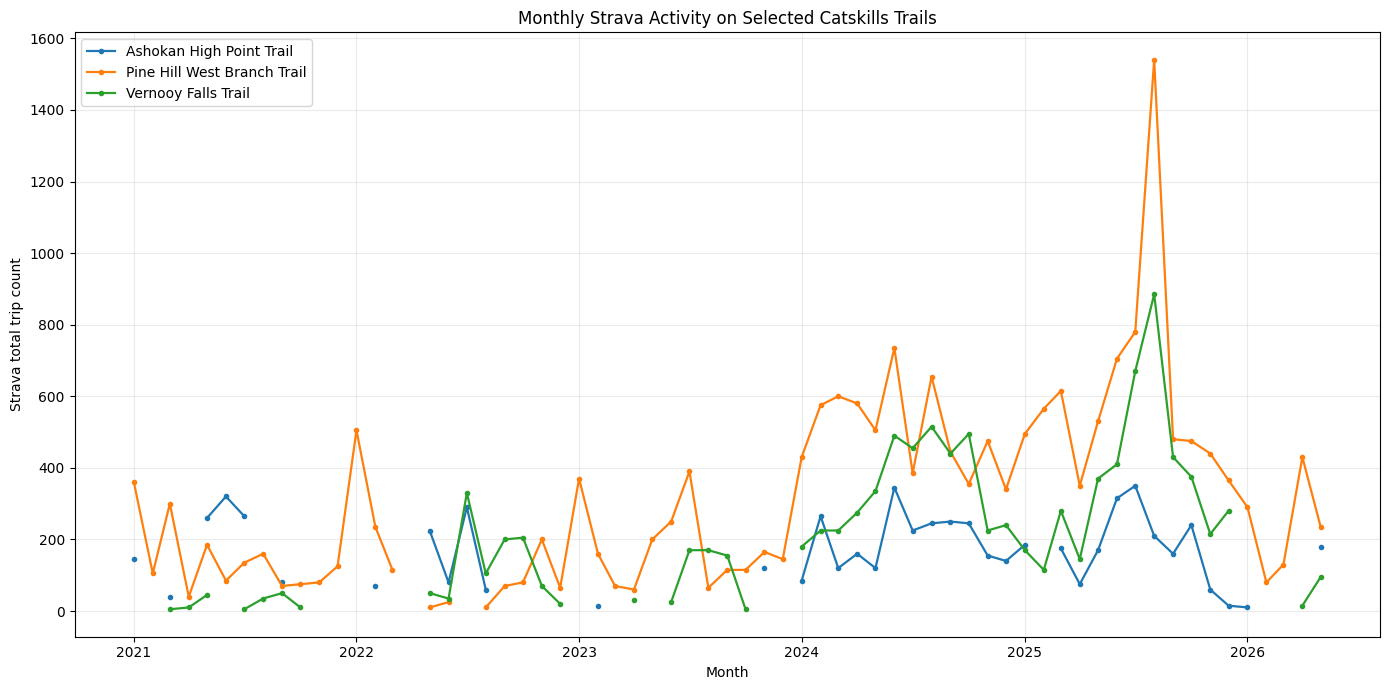

In [21]:
# ============================================================
# 17. PLOT ALL THREE TRAILS
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for trail_name in TRAIL_FILES:

    plot_data = trail_activity_complete[
        trail_activity_complete["trail_name"] == trail_name
    ]

    ax.plot(
        plot_data["month"],
        plot_data["total_trip_count"],
        marker="o",
        markersize=3,
        linewidth=1.6,
        label=trail_name,
    )

ax.set_title(
    "Monthly Strava Activity on Selected Catskills Trails"
)

ax.set_xlabel("Month")
ax.set_ylabel("Strava total trip count")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

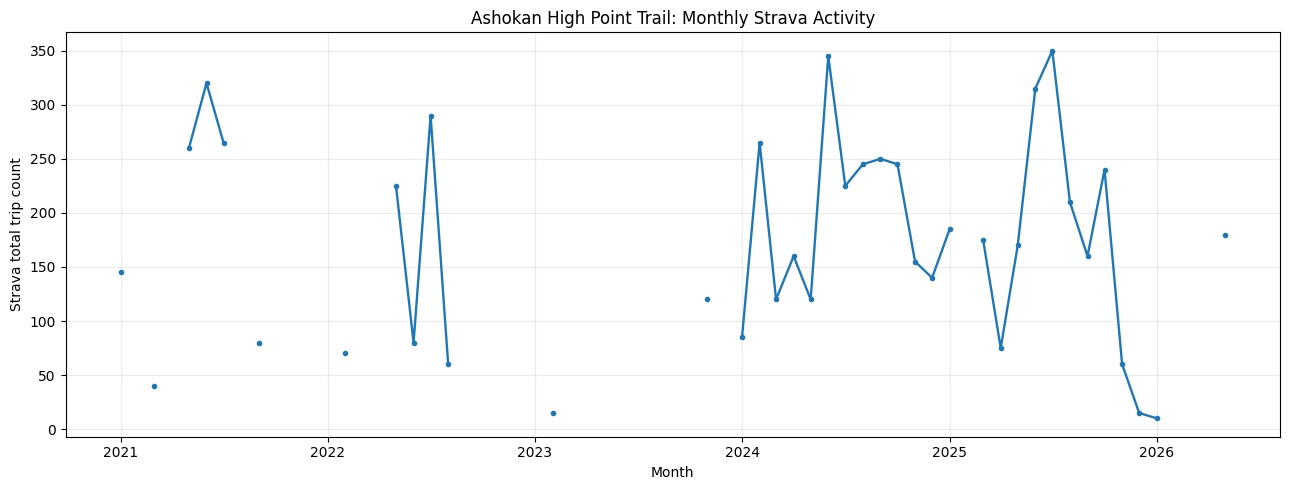

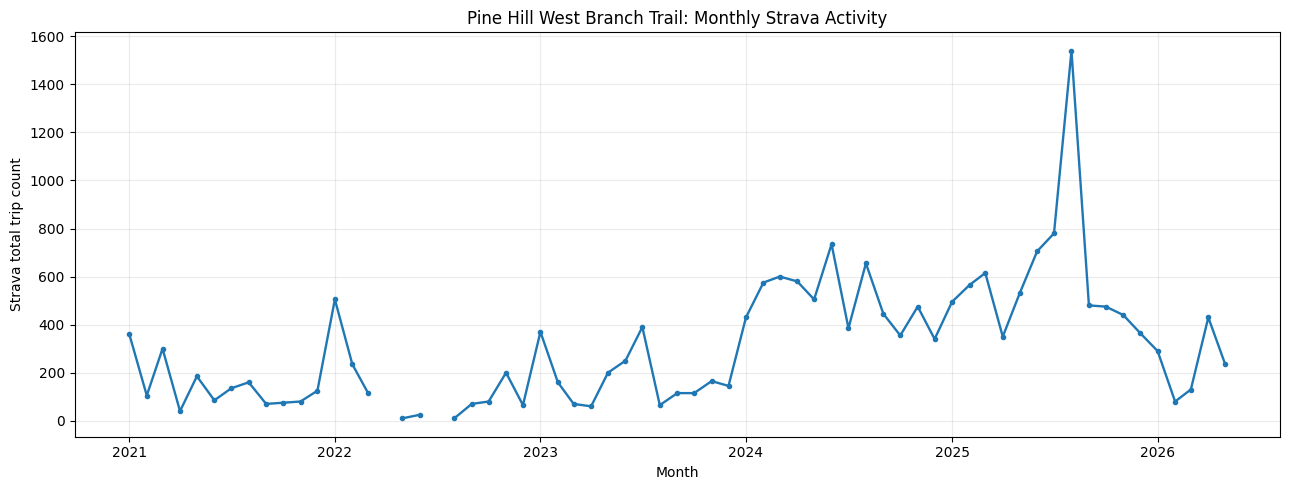

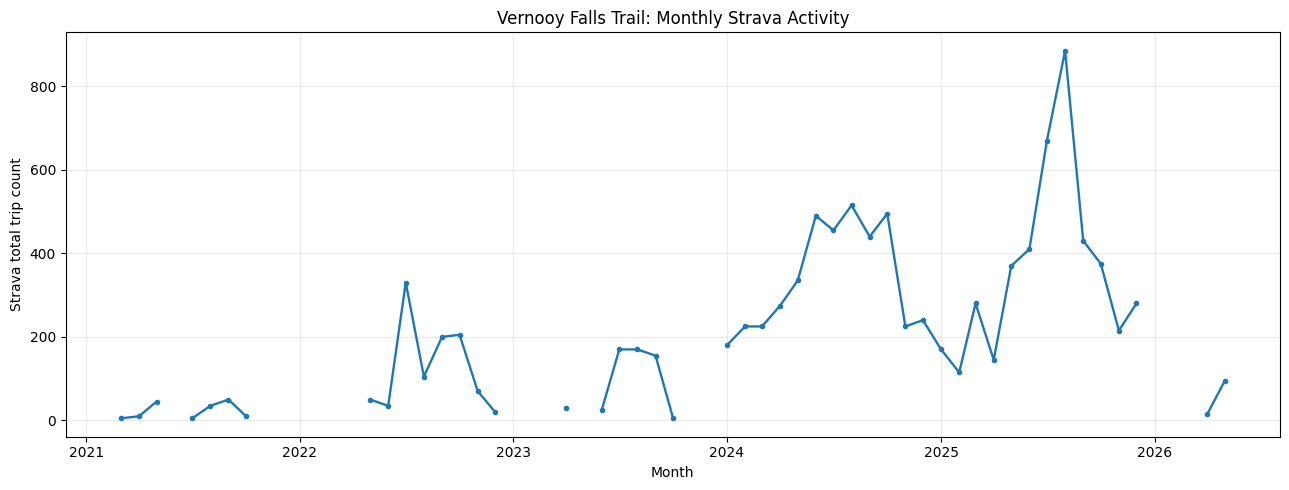

In [22]:
# ============================================================
# 18. INDIVIDUAL TRAIL PLOTS
# ============================================================

for trail_name in TRAIL_FILES:

    plot_data = trail_activity_complete[
        trail_activity_complete["trail_name"] == trail_name
    ].copy()

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(
        plot_data["month"],
        plot_data["total_trip_count"],
        marker="o",
        markersize=3,
        linewidth=1.7,
    )

    ax.set_title(
        f"{trail_name}: Monthly Strava Activity"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Strava total trip count")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# 19. SAVE RESULTS
# ============================================================

activity_output_path = (
    OUTPUT_DIR /
    "three_trails_monthly_strava_activity.csv"
)

edge_output_path = (
    OUTPUT_DIR /
    "three_trails_selected_strava_edges.csv"
)

trail_activity_complete.to_csv(
    activity_output_path,
    index=False,
    date_format="%Y-%m-%d",
)

edge_records = []

for trail_name, edge_set in trail_edge_sets.items():
    for edge_uid in sorted(edge_set):
        edge_records.append({
            "trail_name": trail_name,
            "edge_uid": edge_uid,
            "buffer_meters": BUFFER_METERS,
        })

trail_edges_df = pd.DataFrame(edge_records)

trail_edges_df.to_csv(
    edge_output_path,
    index=False,
)

print("Saved activity:", activity_output_path)
print("Saved selected edges:", edge_output_path)

Saved activity: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trail_outputs/three_trails_monthly_strava_activity.csv
Saved selected edges: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trail_outputs/three_trails_selected_strava_edges.csv


In [24]:
# ============================================================
# OPTIONAL: FIX THE 2026 OVERLAP BY EXCLUDING MARCH 2026
# FROM THE SECOND DAILY DOWNLOAD
# ------------------------------------------------------------
# Run this only if March 2026 appears approximately doubled.
# ============================================================

SECOND_2026_FOLDER_TEXT = "all_edges_daily_2026-03-01-2026-05-31_ped"

def should_keep_daily_date(csv_path, dates):
    if SECOND_2026_FOLDER_TEXT in str(csv_path):
        return dates >= pd.Timestamp("2026-04-01")

    return pd.Series(
        True,
        index=dates.index,
    )